CSV loaded successfully!
Rows: 10841
Columns: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Current IST time: 07:12 PM


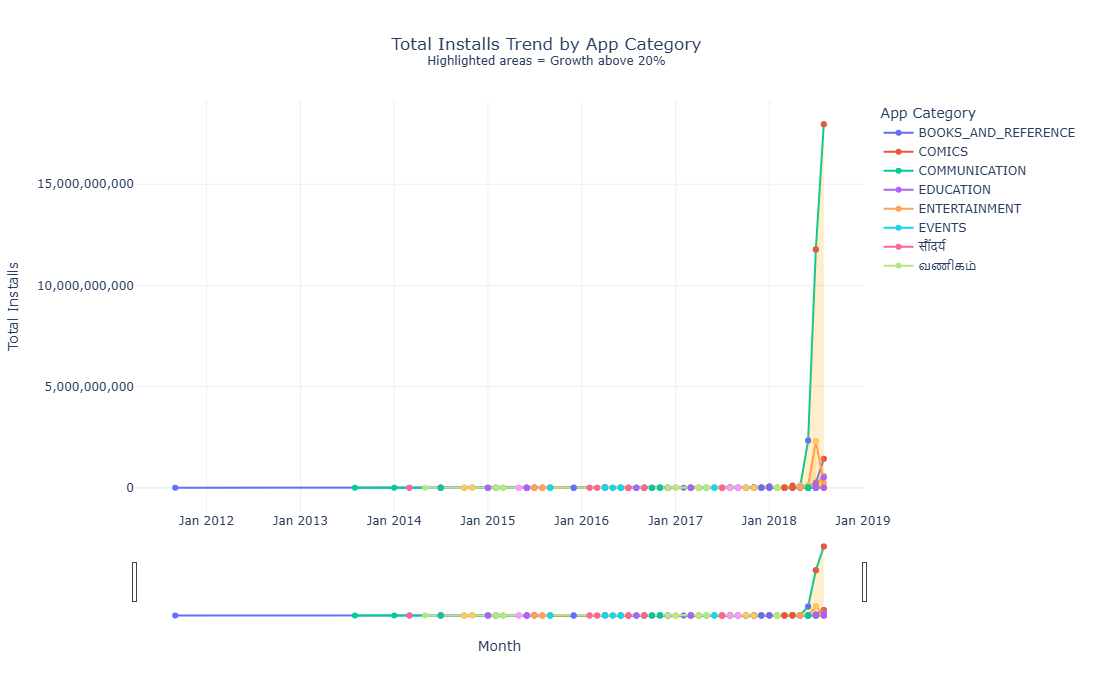


GRAPH CREATED SUCCESSFULLY!
Saved as: play_store_time_series_chart.html

Filtered rows: 852

Categories included:
Category_Display
COMMUNICATION          238
EDUCATION              144
ENTERTAINMENT          143
வணிகம்                 142
BOOKS_AND_REFERENCE    101
COMICS                  41
सौंदर्य                 23
EVENTS                  20
Name: count, dtype: int64

First 20 rows of monthly data:
        Month     Category_Display  Installs_Numeric  Previous_Installs  \
0  2011-09-01  BOOKS_AND_REFERENCE         1000000.0                NaN   
5  2014-07-01  BOOKS_AND_REFERENCE           50000.0          1000000.0   
8  2014-10-01  BOOKS_AND_REFERENCE          500000.0            50000.0   
9  2014-11-01  BOOKS_AND_REFERENCE         5000000.0           500000.0   
11 2015-02-01  BOOKS_AND_REFERENCE           50000.0          5000000.0   
15 2015-06-01  BOOKS_AND_REFERENCE          100000.0            50000.0   
17 2015-07-01  BOOKS_AND_REFERENCE        10000000.0           100000

In [2]:
# ============================================================
# PLAY STORE TIME SERIES LINE CHART
# ============================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from datetime import datetime, timezone, timedelta


# ============================================================
# 1. CSV FILE PATH
# ============================================================

file_path = r"C:\Users\Harshitha.M\Downloads\Play Store Data (1).csv"

df = pd.read_csv(file_path)

print("CSV loaded successfully!")
print("Rows:", len(df))
print("Columns:", list(df.columns))


# ============================================================
# 2. CLEAN COLUMN NAMES
# ============================================================

df.columns = df.columns.str.strip()


# ============================================================
# 3. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [
    "App",
    "Category",
    "Reviews",
    "Installs",
    "Last Updated"
]

missing = [c for c in required_columns if c not in df.columns]

if missing:
    print("\nMissing columns:", missing)
    print("Available columns:", list(df.columns))
else:

    # ========================================================
    # 4. CLEAN REVIEWS
    # ========================================================

    df["Reviews"] = pd.to_numeric(
        df["Reviews"],
        errors="coerce"
    )

    # Reviews > 500
    df = df[df["Reviews"] > 500].copy()


    # ========================================================
    # 5. CLEAN APP NAME
    # ========================================================

    df["App"] = df["App"].astype(str).str.strip()

    # App name should NOT start with X, Y or Z
    df = df[
        ~df["App"].str.upper().str.startswith(("X", "Y", "Z"))
    ].copy()


    # ========================================================
    # 6. CLEAN CATEGORY
    # ========================================================

    df["Category"] = df["Category"].astype(str).str.strip()

    # Category should start with E, C or B
    df = df[
        df["Category"].str.upper().str.startswith(("E", "C", "B"))
    ].copy()


    # ========================================================
    # 7. CLEAN INSTALLS
    # ========================================================

    def clean_installs(value):

        if pd.isna(value):
            return np.nan

        value = str(value).strip()

        value = value.replace("+", "")
        value = value.replace(",", "")

        if value.upper().endswith("M"):
            return float(value[:-1]) * 1000000

        elif value.upper().endswith("K"):
            return float(value[:-1]) * 1000

        else:
            try:
                return float(value)
            except:
                return np.nan


    df["Installs_Numeric"] = df["Installs"].apply(
        clean_installs
    )

    df = df.dropna(
        subset=["Installs_Numeric"]
    ).copy()


    # ========================================================
    # 8. CONVERT DATE
    # ========================================================

    df["Last Updated"] = pd.to_datetime(
        df["Last Updated"],
        errors="coerce"
    )

    df = df.dropna(
        subset=["Last Updated"]
    ).copy()


    # ========================================================
    # 9. CREATE MONTH
    # ========================================================

    df["Month"] = (
        df["Last Updated"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )


    # ========================================================
    # 10. TRANSLATE CATEGORIES
    # ========================================================

    def translate_category(category):

        category = str(category).upper().strip()

        if category == "BEAUTY":
            return "सौंदर्य"

        elif category == "BUSINESS":
            return "வணிகம்"

        elif category == "DATING":
            return "Dating"

        else:
            return category


    df["Category_Display"] = df["Category"].apply(
        translate_category
    )


    # ========================================================
    # 11. GROUP MONTH + CATEGORY
    # ========================================================

    monthly_data = (
        df.groupby(
            ["Month", "Category_Display"],
            as_index=False
        )["Installs_Numeric"]
        .sum()
    )

    monthly_data = monthly_data.sort_values(
        ["Category_Display", "Month"]
    )


    # ========================================================
    # 12. MONTH-OVER-MONTH GROWTH
    # ========================================================

    monthly_data["Previous_Installs"] = (
        monthly_data
        .groupby("Category_Display")
        ["Installs_Numeric"]
        .shift(1)
    )

    monthly_data["MoM_Growth"] = (
        (
            monthly_data["Installs_Numeric"]
            -
            monthly_data["Previous_Installs"]
        )
        /
        monthly_data["Previous_Installs"]
    ) * 100


    # ========================================================
    # 13. CURRENT IST TIME
    # ========================================================

    IST = timezone(timedelta(hours=5, minutes=30))

    current_time = datetime.now(IST)

    print(
        "\nCurrent IST time:",
        current_time.strftime("%I:%M %p")
    )


    # ========================================================
    # 14. CREATE GRAPH
    # ========================================================

    fig = go.Figure()

    categories = (
        monthly_data["Category_Display"]
        .dropna()
        .unique()
    )


    # ========================================================
    # 15. ADD LINES
    # ========================================================

    for category in categories:

        data = monthly_data[
            monthly_data["Category_Display"] == category
        ].sort_values("Month")

        fig.add_trace(
            go.Scatter(
                x=data["Month"],
                y=data["Installs_Numeric"],
                mode="lines+markers",
                name=str(category),

                hovertemplate=
                "<b>Category:</b> %{fullData.name}<br>"
                "<b>Month:</b> %{x|%b %Y}<br>"
                "<b>Total Installs:</b> %{y:,.0f}"
                "<extra></extra>"
            )
        )


    # ========================================================
    # 16. SHADE GROWTH > 20%
    # ========================================================

    for category in categories:

        data = monthly_data[
            monthly_data["Category_Display"] == category
        ].sort_values("Month").reset_index(drop=True)

        for i in range(1, len(data)):

            growth = data.loc[i, "MoM_Growth"]

            if pd.notna(growth) and growth > 20:

                x1 = data.loc[i - 1, "Month"]
                x2 = data.loc[i, "Month"]

                y1 = data.loc[i - 1, "Installs_Numeric"]
                y2 = data.loc[i, "Installs_Numeric"]

                fig.add_trace(
                    go.Scatter(
                        x=[x1, x2, x2, x1],
                        y=[0, 0, y2, y1],
                        fill="toself",
                        fillcolor="rgba(255,165,0,0.20)",
                        line=dict(width=0),
                        showlegend=False,
                        hoverinfo="skip"
                    )
                )


    # ========================================================
    # 17. GRAPH SETTINGS
    # ========================================================

    fig.update_layout(

        title={
            "text":
            "Total Installs Trend by App Category<br>"
            "<sup>Highlighted areas = Growth above 20%</sup>",
            "x": 0.5
        },

        xaxis_title="Month",

        yaxis_title="Total Installs",

        xaxis=dict(
            tickformat="%b %Y",
            rangeslider=dict(visible=True)
        ),

        yaxis=dict(
            tickformat=","
        ),

        hovermode="x unified",

        template="plotly_white",

        legend_title="App Category",

        height=700
    )


    # ========================================================
    # 18. SHOW GRAPH
    # ========================================================

    fig.show()


    # ========================================================
    # 19. SAVE GRAPH
    # ========================================================

    output_file = "play_store_time_series_chart.html"

    fig.write_html(output_file)

    print("\n======================================")
    print("GRAPH CREATED SUCCESSFULLY!")
    print("======================================")

    print("Saved as:", output_file)

    print("\nFiltered rows:", len(df))

    print("\nCategories included:")

    print(
        df["Category_Display"].value_counts()
    )

    print("\nFirst 20 rows of monthly data:")

    print(
        monthly_data.head(20)
    )